# Figure 3 — Melody prioritizes genetic variants influencing DNA methylation (meQTLs)

Reproduces panels **C, D, E, F, G, H, I** from `./Data/Figure3`. Panels **A/B** (model-based in-silico saturation mutagenesis) are reproduced in
**`Figure3_AB_ism.ipynb`** (which loads the Melody-MT model).

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
CSV_DIR = next((os.path.join(r, 'Data', 'Figure3') for r in (os.getcwd(), os.path.dirname(os.getcwd())) if os.path.isdir(os.path.join(r, 'Data', 'Figure3'))), './Data/Figure3')

## Figure 3C — meQTL performance: related-track average vs. single track
Melody-MT Pearson correlation per meQTL dataset, using either a single representative
cell-type track or the average over biologically related tracks. (Grouped bars, GnBu colors.)

/var/folders/f8/4qmbqwxd66qffc_z38kwwzgc0000gn/T/ipykernel_3378/3820442272.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('GnBu', 3)


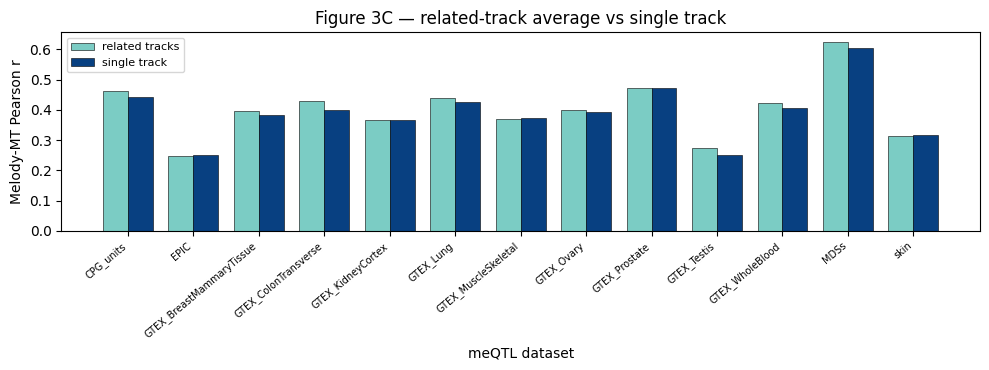

In [2]:
df = pd.read_csv(f'{CSV_DIR}/figure_3C.csv')
sub = df[df['model'] == 'Melody-MT']
datasets = sorted(sub['meQTL_Dataset'].unique())
cmap = mpl.cm.get_cmap('GnBu', 3)
mcol = {'related tracks': cmap(1), 'single track': cmap(2)}
x = np.arange(len(datasets)); w = 0.38
plt.figure(figsize=(10, 3.8))
for k, method in enumerate(['related tracks', 'single track']):
    vals = [sub[(sub['meQTL_Dataset'] == d) & (sub['method'] == method)]['pearson_r'].mean() for d in datasets]
    plt.bar(x + (k - 0.5) * w, vals, w, color=mcol[method], edgecolor='black', linewidth=0.4, label=method)
plt.xticks(x, datasets, rotation=40, ha='right', fontsize=7)
plt.ylabel('Melody-MT Pearson r'); plt.xlabel('meQTL dataset')
plt.title('Figure 3C — related-track average vs single track'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Figure 3D — Melody-MT vs. Melody-ST on meQTL prediction
Each dot is one meQTL dataset; dashed line is y = x. Points above the line favor Melody-MT.

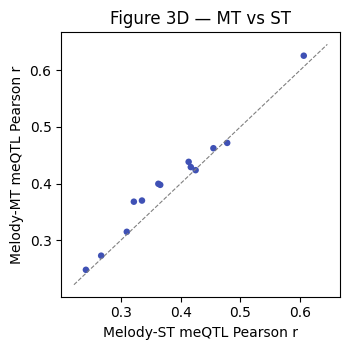

In [3]:
df = pd.read_csv(f'{CSV_DIR}/figure_3D.csv')
plt.figure(figsize=(3.6, 3.6))
plt.scatter(df['st_r'], df['mt_r'], s=22, color='#3F51B5', edgecolor='none')
lo = min(df['st_r'].min(), df['mt_r'].min()) - 0.02
hi = max(df['st_r'].max(), df['mt_r'].max()) + 0.02
plt.plot([lo, hi], [lo, hi], '--', color='0.5', lw=0.8)
plt.xlabel('Melody-ST meQTL Pearson r'); plt.ylabel('Melody-MT meQTL Pearson r')
plt.title('Figure 3D — MT vs ST'); plt.tight_layout(); plt.show()

## Figure 3E — meQTL performance across variant–CpG distances
Distribution (across datasets) of Pearson correlation at increasing distance windows, per model.

/var/folders/f8/4qmbqwxd66qffc_z38kwwzgc0000gn/T/ipykernel_3378/1351388139.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('GnBu', len(models) + 2)


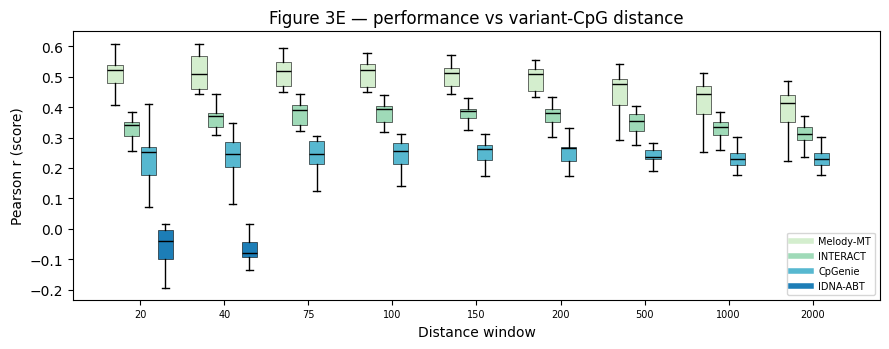

In [4]:
df = pd.read_csv(f'{CSV_DIR}/figure_3E.csv')
models = ['Melody-MT', 'INTERACT', 'CpGenie', 'IDNA-ABT']
dists = sorted(df['distance_window'].unique())
cmap = mpl.cm.get_cmap('GnBu', len(models) + 2)
mcol = {m: cmap(0.3 + 0.6 * i / (len(models) - 1)) if False else cmap(i + 1) for i, m in enumerate(models)}
plt.figure(figsize=(9, 3.6)); ax = plt.gca()
nm = len(models); w = 0.8 / nm
for mi, m in enumerate(models):
    data = [df[(df['distance_window'] == d) & (df['model'] == m)]['score'].dropna().to_numpy() for d in dists]
    pos = np.arange(len(dists)) + (mi - (nm - 1) / 2) * w
    bp = ax.boxplot(data, positions=pos, widths=w * 0.9, patch_artist=True, showfliers=False)
    for b in bp['boxes']:
        b.set_facecolor(mcol[m]); b.set_edgecolor('black'); b.set_linewidth(0.4)
    for med in bp['medians']:
        med.set_color('black')
    ax.plot([], [], color=mcol[m], lw=4, label=m)
ax.set_xticks(range(len(dists))); ax.set_xticklabels(dists, fontsize=7)
ax.set_xlabel('Distance window'); ax.set_ylabel('Pearson r (score)')
ax.set_title('Figure 3E — performance vs variant-CpG distance'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Figure 3F,G — Predicted vs. observed methylation difference (MDSs)
Scatter of Melody-predicted vs. observed effect for the MDSs (F) and GTEx WholeBlood (G)
datasets. (The original uses a broken x-axis; shown here as a single scatter.)

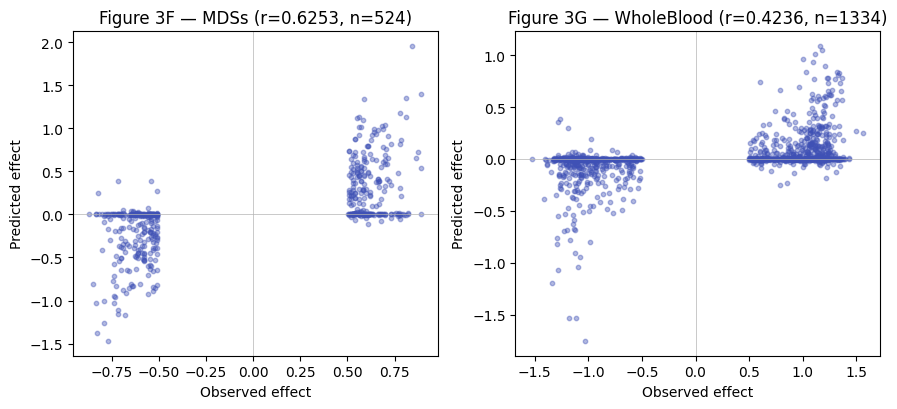

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, (panel, fn, name) in zip(axes, [('F', 'figure_3F.csv', 'MDSs'), ('G', 'figure_3G.csv', 'WholeBlood')]):
    d = pd.read_csv(f'{CSV_DIR}/{fn}')
    r = np.corrcoef(d['observed'], d['predicted'])[0, 1]
    ax.scatter(d['observed'], d['predicted'], alpha=0.4, s=10, color='#3F51B5')
    ax.axhline(0, color='0.7', lw=0.5); ax.axvline(0, color='0.7', lw=0.5)
    ax.set_xlabel('Observed effect'); ax.set_ylabel('Predicted effect')
    ax.set_title(f'Figure 3{panel} — {name} (r={r:.4f}, n={len(d)})')
plt.tight_layout(); plt.show()

## Figure 3H — Cross–cell-type validation of meQTL prediction
Bubble matrix: rows = related tracks, columns = GTEx datasets. Color = Pearson r;
bubble size = within-column rank (largest = best).

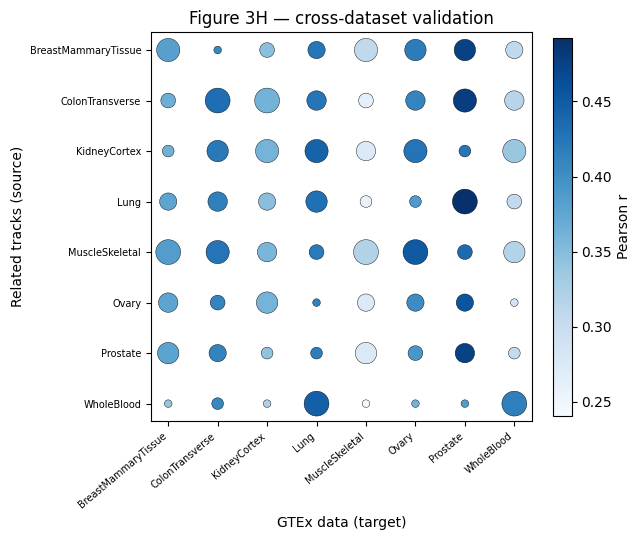

In [6]:
df = pd.read_csv(f'{CSV_DIR}/figure_3H.csv')
piv = df.pivot(index='src_dataset', columns='tgt_dataset', values='pearson_r')
srcs = list(piv.index); tgts = list(piv.columns)
M = piv.to_numpy(dtype=float)
vmin, vmax = np.nanmin(M), np.nanmax(M)
min_s, max_s = 30.0, 320.0
xs, ys, cs, ss = [], [], [], []
for j in range(M.shape[1]):
    col = M[:, j]; valid = np.where(~np.isnan(col))[0]
    if len(valid):
        order = valid[np.argsort(-col[valid])]
        k = len(order)
        for rank, i in enumerate(order):
            size = max_s if k == 1 else min_s + (k - 1 - rank) * (max_s - min_s) / (k - 1)
            xs.append(j); ys.append(i); cs.append(M[i, j]); ss.append(size)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(xs, ys, c=cs, s=ss, cmap='Blues', norm=mpl.colors.Normalize(vmin, vmax),
                edgecolors='k', linewidths=0.3)
ax.set_xticks(range(len(tgts))); ax.set_xticklabels([t.replace('GTEX_', '') for t in tgts], rotation=40, ha='right', fontsize=7)
ax.set_yticks(range(len(srcs))); ax.set_yticklabels([s.replace('GTEX_', '') for s in srcs], fontsize=7)
ax.set_xlabel('GTEx data (target)'); ax.set_ylabel('Related tracks (source)'); ax.invert_yaxis()
plt.colorbar(sc, ax=ax, fraction=0.045, label='Pearson r')
ax.set_title('Figure 3H — cross-dataset validation'); plt.tight_layout(); plt.show()

## Figure 3I — meQTL performance vs. training step
Mean and median meQTL Pearson r across datasets as a function of training step.

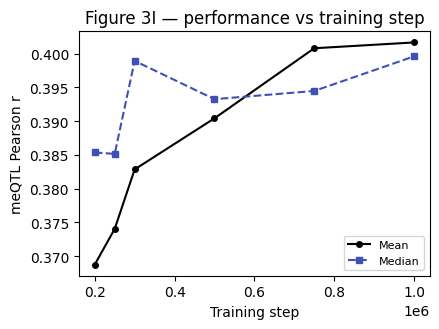

In [7]:
df = pd.read_csv(f'{CSV_DIR}/figure_3I.csv')
steps = sorted(df['ckpt_step'].unique())
means = [df[df['ckpt_step'] == s]['pearson_r'].mean() for s in steps]
medians = [df[df['ckpt_step'] == s]['pearson_r'].median() for s in steps]
plt.figure(figsize=(4.5, 3.4))
plt.plot(steps, means, '-o', color='black', ms=4, label='Mean')
plt.plot(steps, medians, '--s', color='#3F51B5', ms=4, label='Median')
plt.xlabel('Training step'); plt.ylabel('meQTL Pearson r')
plt.title('Figure 3I — performance vs training step'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()